In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [23]:
def sigmoid(z):
    s = 1/(1 + np.exp(-z))
    return s

In [24]:
df = pd.read_csv("C:/Users/shami/Downloads/archive (1)/student_exam_performance_dataset.csv")
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [25]:
df['pass_fail'] = df['pass_fail'].map({
    'Pass' : 1,
    'Fail' : 0
})

In [26]:
Y = df['pass_fail'].to_numpy()
Y.shape

(10000,)

In [27]:
df = df.drop(['student_id','final_exam_score','previous_gpa','grade_category','pass_fail'],axis = 1)
df = pd.get_dummies(df,columns = ['gender','parental_education','family_income','internet_access','study_environment','tutoring'])
df.head()

,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,...,family_income_High,family_income_Low,family_income_Medium,internet_access_No,internet_access_Yes,study_environment_Moderate,study_environment_Noisy,study_environment_Quiet,tutoring_No,tutoring_Yes
0,17,2.98,96.5,6.05,0.1,80.5,68.7,1,42.8,62.4,...,False,False,True,False,True,False,False,True,False,True
1,18,4.45,95.7,6.96,2.9,70.9,92.6,0,77.9,73.5,...,False,True,False,False,True,False,False,True,False,True
2,17,3.75,76.0,7.02,2.4,77.6,45.8,4,53.5,38.3,...,False,False,True,True,False,False,False,True,False,True
3,18,2.03,72.6,6.23,3.5,63.5,72.9,4,28.3,23.5,...,False,False,True,False,True,False,False,True,True,False
4,18,5.14,87.3,8.54,2.1,71.8,55.7,0,74.7,54.9,...,False,False,True,False,True,False,False,True,True,False


In [28]:
scaler = StandardScaler()
df = pd.DataFrame(scaler.fit_transform(df),columns = df.columns,index = df.index)
df.head()

,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,...,family_income_High,family_income_Low,family_income_Medium,internet_access_No,internet_access_Yes,study_environment_Moderate,study_environment_Noisy,study_environment_Quiet,tutoring_No,tutoring_Yes
0,0.457028,-0.033669,1.240568,-0.977038,-1.670932,0.073282,-0.076188,-0.716098,-0.483008,0.946513,...,-0.493899,-0.650137,0.986491,-0.33592,0.33592,-0.807511,-0.496873,1.206314,-1.528981,1.528981
1,1.347748,1.212964,1.156434,-0.059389,0.264537,-0.624263,1.554261,-1.411812,2.046091,1.777417,...,-0.493899,1.538139,-1.013694,-0.33592,0.33592,-0.807511,-0.496873,1.206314,-1.528981,1.528981
2,0.457028,0.619329,-0.915345,0.001115,-0.081082,-0.137435,-1.638418,1.371043,0.287971,-0.857523,...,-0.493899,-0.650137,0.986491,2.97690,-2.97690,-0.807511,-0.496873,1.206314,-1.528981,1.528981
3,1.347748,-0.839317,-1.272911,-0.795525,0.679280,-1.161954,0.210334,1.371043,-1.527792,-1.965396,...,-0.493899,-0.650137,0.986491,-0.33592,0.33592,-0.807511,-0.496873,1.206314,0.654030,-0.654030
4,1.347748,1.798118,0.273036,1.533892,-0.288454,-0.558868,-0.963044,-1.411812,1.815517,0.385091,...,-0.493899,-0.650137,0.986491,-0.33592,0.33592,-0.807511,-0.496873,1.206314,0.654030,-0.654030


In [29]:
X = df.to_numpy()
X.shape

(10000, 28)

In [30]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    test_size = 0.2,
    random_state = 0
)

In [31]:
X_train = X_train.T
Y_train = Y_train.reshape(1,8000)

In [32]:
n_x,n_h,n_y = X_train.shape[0],4,Y_train.shape[0]

In [33]:
m = X_train.shape[1]

In [34]:
W1 = np.random.randn(n_h,n_x) * 0.01
b1 = np.zeros((n_h,1))
W2 = np.random.randn(n_y,n_h) * 0.01
b2 = np.zeros((n_y,1))
a = 0.1
print(W1,'\n',b1,'\n',W2,'\n',b2)
losses = []

[[-0.01264135 -0.01489881 -0.00239599 -0.01232972  0.03022052 -0.01057787
   0.01869758 -0.00467141 -0.00183553  0.00376429 -0.00746635  0.01028374
  -0.01976283  0.00397581  0.00672145  0.00740954 -0.01163372 -0.00203907
   0.00133212  0.00534729 -0.00603316 -0.00982971  0.00307277 -0.01873403
  -0.00184035  0.00382142 -0.00629713 -0.01533101]
 [ 0.01447036  0.0031852   0.00241327 -0.02084298 -0.02003669 -0.00811461
  -0.00149312 -0.00021382 -0.01245487 -0.01782004 -0.00084914  0.01325459
   0.01400903 -0.0028336  -0.00708075 -0.00986379 -0.00323503  0.00927113
   0.00845895  0.0094327  -0.00596066  0.00139187 -0.00870324 -0.00826665
  -0.00315106 -0.00163879 -0.01161657  0.00106877]
 [-0.00271542 -0.01594019  0.01083579  0.00226187  0.02027533 -0.0064294
   0.0213967   0.00142336 -0.00132198  0.00037369 -0.00939904 -0.00614416
   0.01089181 -0.00298767  0.00404526 -0.01015556  0.00477206 -0.00573058
   0.01550957  0.00950512 -0.01249538 -0.00902825 -0.00069726  0.00398883
  -0.015940

In [35]:
for i in range(1000):
    Z1 = np.dot(W1,X_train) + b1
    A1 = np.tanh(Z1)
    Z2 = np.dot(W2,A1) + b2
    A2 = sigmoid(Z2)
    logprobs = np.multiply(np.log(A2),Y_train) + np.multiply(np.log(1 - A2),1 - Y_train)
    J = -1/m * np.sum(logprobs)
    losses.append(J)
    dZ2 = A2 - Y_train
    dW2 = 1/m * np.dot(dZ2,A1.T)
    db2 = 1/m * np.sum(dZ2,axis = 1,keepdims = True)
    dZ1 = np.dot(W2.T,dZ2) * (1 - np.power(A1,2))
    dW1 = 1/m * np.dot(dZ1,X_train.T)
    db1 = 1/m * np.sum(dZ1,axis = 1,keepdims = True)
    W1 -= a * dW1
    W2 -= a * dW2
    b1 -= a * db1
    b2 -= a * db2

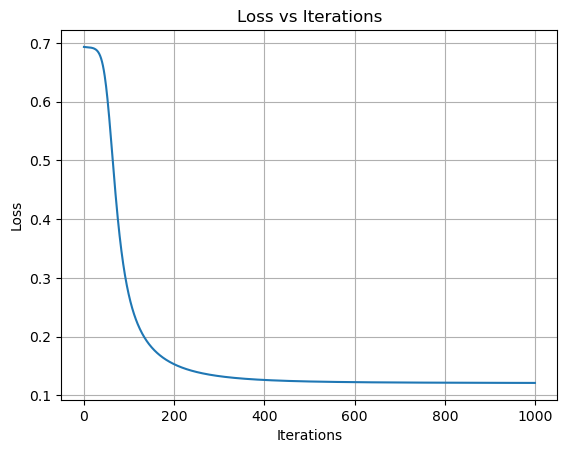

In [36]:
plt.plot(losses)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")

plt.grid(True)

plt.show()

In [37]:
class NeuralNetwork():
    def __init__(self,W1,b1,W2,b2):
        self.W1 = W1
        self.b1 = b1
        self.W2 = W2
        self.b2 = b2
    def predict(self, X_test):
        X_test = X_test.T
        m = X_test.shape[1]
        Z1 = np.dot(self.W1, X_test) + b1
        A1 = np.tanh(Z1)
        Z2 = np.dot(self.W2, A1) + b2
        A2 = sigmoid(Z2)
        Y_pred = np.where(A2 > 0.5, 1, 0)
        return Y_pred

In [38]:
nn = NeuralNetwork(W1,b1,W2,b2)
Y_pred = nn.predict(X_test)
accuracy = np.sum(Y_pred == Y_test) / 2000 * 100

In [39]:
print("Accuracy =",accuracy)

Accuracy = 94.95


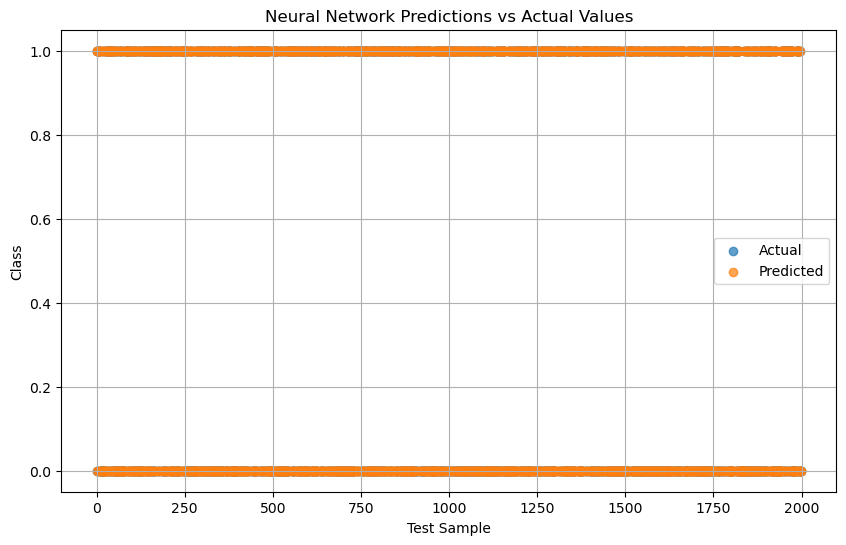

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Predictions
Y_pred = nn.predict(X_test)

# Flatten arrays
y_true = np.array(Y_test).flatten()
y_pred = np.array(Y_pred).flatten()

plt.figure(figsize=(10,6))
plt.scatter(range(len(y_true)), y_true, label='Actual', alpha=0.7)
plt.scatter(range(len(y_pred)), y_pred, label='Predicted', alpha=0.7)

plt.xlabel('Test Sample')
plt.ylabel('Class')
plt.title('Neural Network Predictions vs Actual Values')
plt.legend()
plt.grid(True)
plt.show()

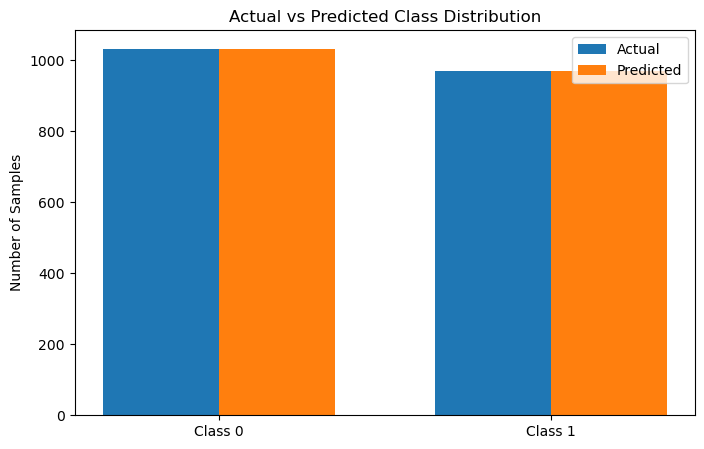

In [41]:
import matplotlib.pyplot as plt
import numpy as np

y_true = Y_test.flatten()
y_pred = Y_pred.flatten()

actual_counts = [np.sum(y_true == 0), np.sum(y_true == 1)]
pred_counts = [np.sum(y_pred == 0), np.sum(y_pred == 1)]

x = np.arange(2)
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, actual_counts, width, label='Actual')
plt.bar(x + width/2, pred_counts, width, label='Predicted')

plt.xticks(x, ['Class 0', 'Class 1'])
plt.ylabel('Number of Samples')
plt.title('Actual vs Predicted Class Distribution')
plt.legend()
plt.show()

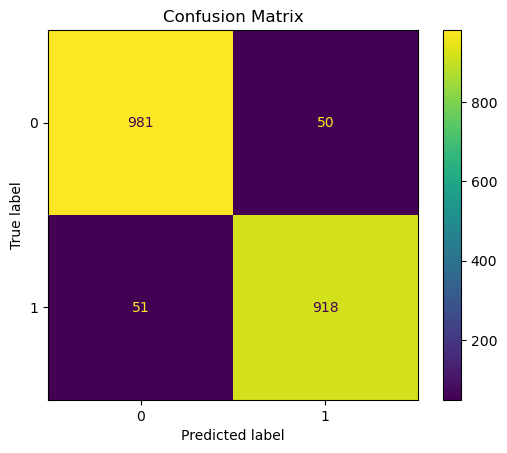

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred.flatten())

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()